# Optional CTR resolution modeling

This example compares the unbroadened structure factor with fast convolution on the existing irregular $L$ points and slow deterministic sampling of the crystal structure factor. Resolution is applied to $|F|^2$ and returned as the effective amplitude $\sqrt{I_{\mathrm{res}}}$.

In [1]:
%matplotlib widget
import copy
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize

repository_root = Path.cwd().resolve()
while not (repository_root / "pyproject.toml").exists():
    if repository_root.parent == repository_root:
        raise RuntimeError("Run this notebook from within the orGUI repository")
    repository_root = repository_root.parent
sys.path.insert(0, str(repository_root))

from orgui.datautils.xrayutils import (
    CTRcalc,
    CTRopt,
    CTRplotutil,
    CTRresolution,
    HKLVlieg,
)

## Load an existing crystal and CTR sampling positions

The bundled calculated dataset supplies the measured $H$, $K$, and irregular $L$ positions. One rod is selected to keep the comparison quick and readable.

In [2]:
test_data_dir = (
    repository_root
    / "orgui"
    / "datautils"
    / "xrayutils"
    / "test"
    / "testdata"
)
crystal = CTRcalc.SXRDCrystal.fromFile("RuO2_TiO2_Poisson_etching.xtal")
measured = CTRplotutil.CTRCollection.fromANAROD("2V036_dataset_0003.dat",
    RODexport=True,
)
positions = CTRplotutil.CTRCollection(
    [measured[(1.0, 1.0)]],
    name="(1, 1) sampling positions",
)
calculated = positions.generateCollectionFromXtal(crystal)

## Calculate the diffractometer angles

Angle-dependent widths require the central point's Vlieg `gamma` and `delta` angles in radians. `CTRCollection.calcAnglesZmode` stores all six angles on every rod.

In [3]:
ub_calculator = HKLVlieg.UBCalculator(crystal.reference_uc, energy=70.0)
ub_calculator.defaultU_GID()
vlieg_angles = HKLVlieg.VliegAngles(ub_calculator)
angle_options = {"fixedangle": np.deg2rad(0.1), "fixed": "in"}
positions.calcAnglesZmode(vlieg_angles, **angle_options)
angl = calculated.calcAnglesZmode(vlieg_angles, **angle_options)
# no output

## Define the four initial resolution variants

For a box, `delta_l_0` is the full support width. For a Gaussian it is the FWHM. Nonzero `delta_l_1` and `delta_l_2` apply $\Delta L = \Delta L_0 + \Delta L_1 |\sin(\gamma)| + \Delta L_2 |\sin(\delta)|$. All widths are in reciprocal lattice units.

In [4]:
constant_box = CTRresolution.BoxResolution(delta_l_0=0.025)
constant_gaussian = CTRresolution.GaussianResolution(delta_l_0=0.025)
angle_box = CTRresolution.BoxResolution(
    delta_l_0=0.015,
    delta_l_1=0.08,
    delta_l_2=0.04,
)
angle_gaussian = CTRresolution.GaussianResolution(
    delta_l_0=0.015,
    delta_l_1=0.08,
    delta_l_2=0.04,
)

## Apply fast convolution and slow sampling

The fast method uses only the existing irregular points. The slow method below reevaluates `crystal.F` with 25-point Gauss-Hermite quadrature around every central point.

In [5]:
fast_box = CTRresolution.fast_convolve(calculated, constant_box)
fast_gaussian = CTRresolution.fast_convolve(calculated, constant_gaussian)
fast_angle_box = CTRresolution.fast_convolve(calculated, angle_box)
slow_angle_gaussian = CTRresolution.sample_structure_factor(
    positions,
    crystal,
    angle_gaussian,
    quadrature_order=25,
)

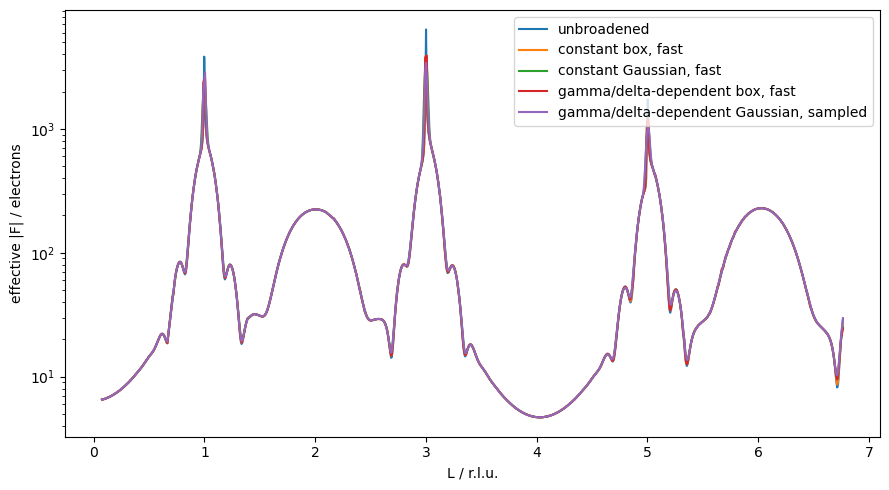

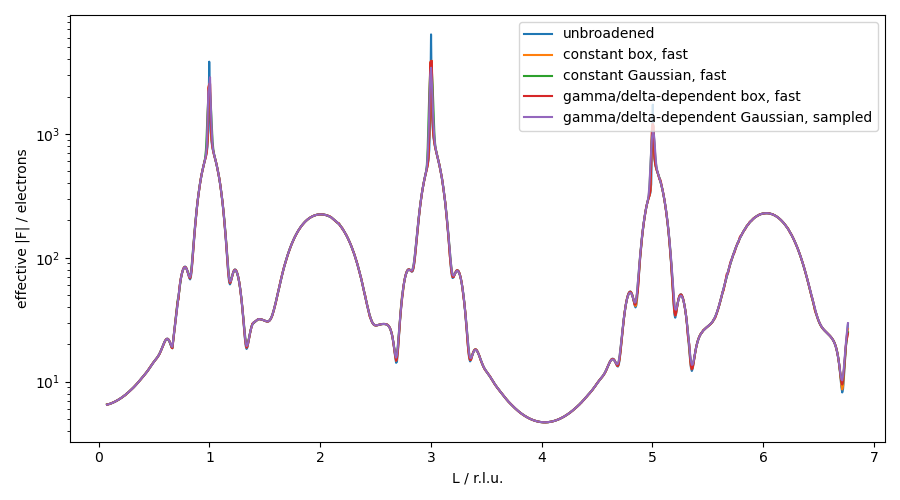

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(calculated[0].l, calculated[0].sfI, label="unbroadened")
ax.semilogy(fast_box[0].l, fast_box[0].sfI, label="constant box, fast")
ax.semilogy(
    fast_gaussian[0].l,
    fast_gaussian[0].sfI,
    label="constant Gaussian, fast",
)
ax.semilogy(
    fast_angle_box[0].l,
    fast_angle_box[0].sfI,
    label="gamma/delta-dependent box, fast",
)
ax.semilogy(
    slow_angle_gaussian[0].l,
    slow_angle_gaussian[0].sfI,
    label="gamma/delta-dependent Gaussian, sampled",
)
ax.set_xlabel("L / r.l.u.")
ax.set_ylabel("effective |F| / electrons")
ax.legend()
fig.tight_layout()
fig

## Fit resolution widths with `CTRopt`

`fit_resolution` places $\Delta L_0$, $\Delta L_1$, and $\Delta L_2$ at the start of the native optimizer parameter vector. The optimizer caches the Z-mode angles and its calculated CTR collection. `calculation="convolve"` uses the fast existing-grid model during the fit; use `"sample"` for quadrature sampling instead. The selected ANAROD file has no uncertainties, so this illustrative fit assigns 5% relative amplitude uncertainties; replace them with measured uncertainties for scientific use.

In [ ]:
fit_positions = copy.deepcopy(positions)
for ctr in fit_positions:
    ctr.err = 0.05 * np.maximum(ctr.sfI, np.finfo(np.float64).eps)

optimizer = CTRopt.CTROptAngleCorrection(crystal, fit_positions)
# Preserve the film model's identity-keyed stacking state for this example.
optimizer.xtal = crystal
optimizer.set_scale_policy_default("F", "scaled")
optimizer.calc_resolution_angles_zmode(vlieg_angles, **angle_options)
optimizer.fit_resolution(
    CTRresolution.GaussianResolution(0.015, 0.04, 0.02),
    lower_bounds=(0.0, 0.0, 0.0),
    higher_bounds=(0.10, 0.20, 0.10),
    calculation="convolve",
)
optimizer.prepareFit()

result = optimize.least_squares(
    optimizer.weighted_residues,
    optimizer.get_parameters(),
    bounds=optimizer.get_bounds(),
    max_nfev=100,
)
optimizer.flat_prediction(result.x)

print(dict(zip(optimizer.fitparnames, result.x)))
print(f"cost = {result.cost:.6g}; evaluations = {result.nfev}")

In [ ]:
fitted = optimizer.calculated_CTRs[0]
observed = optimizer.CTRs[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(observed.l, observed.sfI, observed.err, fmt="o", label="observed")
ax.semilogy(fitted.l, fitted.sfI, label="fitted Gaussian resolution")
ax.set_xlabel("L / r.l.u.")
ax.set_ylabel("effective |F| / electrons")
ax.legend()
fig.tight_layout()
fig